# Model Comparison: Saved Models on the Held-Out Test Set
**IT2011 AIML, Group MLB-B8G1-03** | Author: `<student name / ID>`

This notebook loads the twelve saved final models (eleven supervised classifiers and K-Means) and evaluates them in **one consistent way**:
test accuracy (with 95% CI), macro-F1, per-class recall, confusion matrices, 5-fold CV (mean ± std, same splits for every model), and pairwise McNemar tests.

**Run order:** Cleaning → Outlier → Scaling → Feature Engineering → Feature Selection → PCA → all model notebooks → this notebook.

The test set is used here for reporting only. No model is re-tuned or re-selected in this notebook.

**K-Means is unsupervised.** It is evaluated on the test set through its cluster-to-label mapping, but it is excluded from cross-validation (it has no CV accuracy).

## 1. Setup and configuration

In [12]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest
from sklearn.base import clone
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

warnings.filterwarnings("ignore", category=UserWarning)

RESULTS = Path("../results")
OUT     = RESULTS / "outputs"
MODELS  = RESULTS / "model_trained_files"
FIGS    = RESULTS / "eda_visualizations"
FIGS.mkdir(parents=True, exist_ok=True)

LABELS = ["Low", "Medium", "High"]     # target values 0, 1, 2
SEED   = 42

# feature set name -> (train csv, test csv)
FEATURE_SETS = {
    "anova_top10": (OUT / "Selected" / "train_top10_features.csv",
                    OUT / "Selected" / "test_top10_features.csv"),
    "rf_top10":    (OUT / "Selected" / "train_rf_top10_features.csv",
                    OUT / "Selected" / "test_rf_top10_features.csv"),
    "pca":         (OUT / "PCA" / "pca_train.csv",
                    OUT / "PCA" / "pca_test.csv"),
}

# model name -> (pickle file, feature set it was trained on, version label for the report)
REGISTRY = {
    "KNN":                 ("knn_model.pkl",                 "anova_top10", "Tuned"),
    "Logistic Regression": ("logistic_regression_model.pkl", "anova_top10", "Tuned"),
    "Naive Bayes":         ("naive_bayes.pkl",               "anova_top10", "Tuned"),
    "SVM":                 ("svm_model.pkl",                 "pca",         "Untuned (default rbf)"),
    "Random Forest":       ("random_forest_model.pkl",       "rf_top10",    "Tuned"),
    "MLP":                 ("mlp_tuned.pkl",                 "pca",         "Tuned (PCA)"),
    "Gradient Boosting":   ("gradient_boosting_model.pkl",   "pca",         "Tuned (PCA)"),
    "Decision Tree":       ("decision_tree_model.pkl",       "pca",         "Tuned (PCA)"),
    "Extra Trees":         ("extra_trees_model.pkl",         "anova_top10", "Tuned"),
    "LDA":                 ("lda_model.pkl",                 "anova_top10", "Tuned"),
    "QDA":                 ("qda_model.pkl",                 "anova_top10", "Tuned"),
    "K-Means":             ("kmeans_model.pkl",              "anova_top10", "Tuned (unsupervised)"),
}
UNSUPERVISED = {"K-Means"}   # saved as {"model": KMeans, "mapping": {cluster: stress level}}

## 2. Load data and saved models (with sanity checks)

In [13]:
data = {}
for key, (tr, te) in FEATURE_SETS.items():
    tr_df, te_df = pd.read_csv(tr), pd.read_csv(te)
    cols = [c for c in tr_df.columns if c != "target"]
    data[key] = dict(X_train=tr_df[cols], y_train=tr_df["target"],
                     X_test=te_df[cols],  y_test=te_df["target"], cols=cols)
    print(f"{key:12s} train={tr_df.shape}  test={te_df.shape}  features={len(cols)}")

# every feature set must describe the same test rows in the same order (needed for McNemar)
ref = data["pca"]["y_test"].to_numpy()
for key, d in data.items():
    assert np.array_equal(ref, d["y_test"].to_numpy()), f"Test rows differ for feature set '{key}'"
y_true = ref
n_test = len(y_true)
print("\nAll feature sets share the same test rows. n_test =", n_test)

anova_top10  train=(880, 11)  test=(220, 11)  features=10
rf_top10     train=(880, 11)  test=(220, 11)  features=10
pca          train=(880, 3)  test=(220, 3)  features=2

All feature sets share the same test rows. n_test = 220


In [14]:
class ClusterClassifier:
    # wraps a fitted KMeans and its cluster -> stress level mapping so it behaves like a classifier
    def __init__(self, km, mapping):
        self.km, self.mapping = km, mapping
        self.n_features_in_ = km.n_features_in_
        self.feature_names_in_ = getattr(km, "feature_names_in_", None)
    def predict(self, X):
        return np.array([self.mapping[c] for c in self.km.predict(X)])

models = {}
for name, (pkl, fs, version) in REGISTRY.items():
    m = joblib.load(MODELS / pkl)
    if isinstance(m, dict) and "model" in m:                  # K-Means file
        m = ClusterClassifier(m["model"], m["mapping"])
    cols = data[fs]["cols"]

    n_in = getattr(m, "n_features_in_", None)
    if n_in is not None and n_in != len(cols):
        raise ValueError(f"{name}: '{pkl}' expects {n_in} features but feature set '{fs}' has {len(cols)}. "
                         f"The wrong model was probably saved (e.g. a PCA-fitted model for a Top-10 notebook).")
    names_in = getattr(m, "feature_names_in_", None)
    if names_in is not None and list(names_in) != cols:
        raise ValueError(f"{name}: feature names/order in '{pkl}' differ from feature set '{fs}'.")
    models[name] = m
    print(f"OK  {name:20s} {type(m).__name__:24s} features={len(cols):2d} ({fs})")

OK  KNN                  KNeighborsClassifier     features=10 (anova_top10)
OK  Logistic Regression  LogisticRegression       features=10 (anova_top10)
OK  Naive Bayes          GaussianNB               features=10 (anova_top10)
OK  SVM                  SVC                      features= 2 (pca)
OK  Random Forest        RandomForestClassifier   features=10 (rf_top10)
OK  MLP                  MLPClassifier            features= 2 (pca)
OK  Gradient Boosting    HistGradientBoostingClassifier features= 2 (pca)
OK  Decision Tree        DecisionTreeClassifier   features= 2 (pca)
OK  Extra Trees          ExtraTreesClassifier     features=10 (anova_top10)
OK  LDA                  LinearDiscriminantAnalysis features=10 (anova_top10)
OK  QDA                  QuadraticDiscriminantAnalysis features=10 (anova_top10)
OK  K-Means              ClusterClassifier        features=10 (anova_top10)


## 3. Test-set evaluation

In [15]:
def wilson_ci(k, n, z=1.96):
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half

preds, cms, rows = {}, {}, []
for name, (pkl, fs, version) in REGISTRY.items():
    p = models[name].predict(data[fs]["X_test"])
    preds[name] = p
    cm = confusion_matrix(y_true, p, labels=[0, 1, 2])
    cms[name] = cm
    rec = recall_score(y_true, p, average=None, labels=[0, 1, 2])
    k = int((p == y_true).sum())
    lo, hi = wilson_ci(k, n_test)
    rows.append({
        "Model": name, "Final model": version, "Features": fs,
        "Correct": k, "Test acc": k / n_test, "Acc 95% CI low": lo, "Acc 95% CI high": hi,
        "Macro-F1": f1_score(y_true, p, average="macro"),
        "Macro-precision": precision_score(y_true, p, average="macro"),
        "Recall Low": rec[0], "Recall Medium": rec[1], "Recall High": rec[2],
        "High->Low errors": int(cm[2, 0]), "Low->High errors": int(cm[0, 2]),
    })

results = pd.DataFrame(rows).set_index("Model")
show = results[["Final model", "Test acc", "Macro-F1", "Recall Low", "Recall Medium",
                "Recall High", "High->Low errors", "Low->High errors"]]
display(show.round(3))
results.to_csv(OUT / "model_comparison_results.csv")

,Final model,Test acc,Macro-F1,Recall Low,Recall Medium,Recall High,High->Low errors,Low->High errors
Model,,,,,,,,
KNN,Tuned,0.891,0.891,0.824,0.944,0.905,3,6
Logistic Regression,Tuned,0.891,0.892,0.878,0.889,0.905,7,8
Naive Bayes,Tuned,0.895,0.898,0.824,0.889,0.973,2,13
SVM,Untuned (default rbf),0.895,0.897,0.851,0.889,0.946,4,11
Random Forest,Tuned,0.886,0.886,0.851,0.931,0.878,3,5
MLP,Tuned (PCA),0.900,0.902,0.838,0.889,0.973,2,12
Gradient Boosting,Tuned (PCA),0.886,0.886,0.905,0.889,0.865,5,2
Decision Tree,Tuned (PCA),0.882,0.882,0.905,0.931,0.811,8,0
Extra Trees,Tuned,0.886,0.887,0.824,0.903,0.932,3,11


## 4. 5-fold cross-validation (same splits and metrics for every model)

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_rows = []
for name, (pkl, fs, version) in REGISTRY.items():
    if name in UNSUPERVISED:          # no CV accuracy for an unsupervised model
        cv_rows.append({"Model": name, "CV acc mean": np.nan, "CV acc std": np.nan,
                        "CV F1 mean": np.nan, "CV F1 std": np.nan})
        continue
    d = data[fs]
    r = cross_validate(clone(models[name]), d["X_train"], d["y_train"], cv=cv,
                       scoring=["accuracy", "f1_macro"], n_jobs=-1)
    cv_rows.append({"Model": name,
                    "CV acc mean": r["test_accuracy"].mean(), "CV acc std": r["test_accuracy"].std(),
                    "CV F1 mean": r["test_f1_macro"].mean(),  "CV F1 std": r["test_f1_macro"].std()})

cv_df = pd.DataFrame(cv_rows).set_index("Model")
display(cv_df.round(3))
cv_df.to_csv(OUT / "model_comparison_cv.csv")

# NOTE: features were selected on the full training set before this CV, so these CV scores
# can be slightly optimistic. State this as a limitation in the report.

,CV acc mean,CV acc std,CV F1 mean,CV F1 std
Model,,,,
KNN,0.885,0.030,0.885,0.030
Logistic Regression,0.872,0.032,0.872,0.032
Naive Bayes,0.889,0.028,0.891,0.028
SVM,0.870,0.026,0.873,0.025
Random Forest,0.874,0.032,0.874,0.033
MLP,0.886,0.023,0.888,0.022
Gradient Boosting,0.872,0.028,0.872,0.028
Decision Tree,0.875,0.040,0.875,0.039
Extra Trees,0.878,0.032,0.879,0.032


## 5. Confusion matrices (one style for all models)

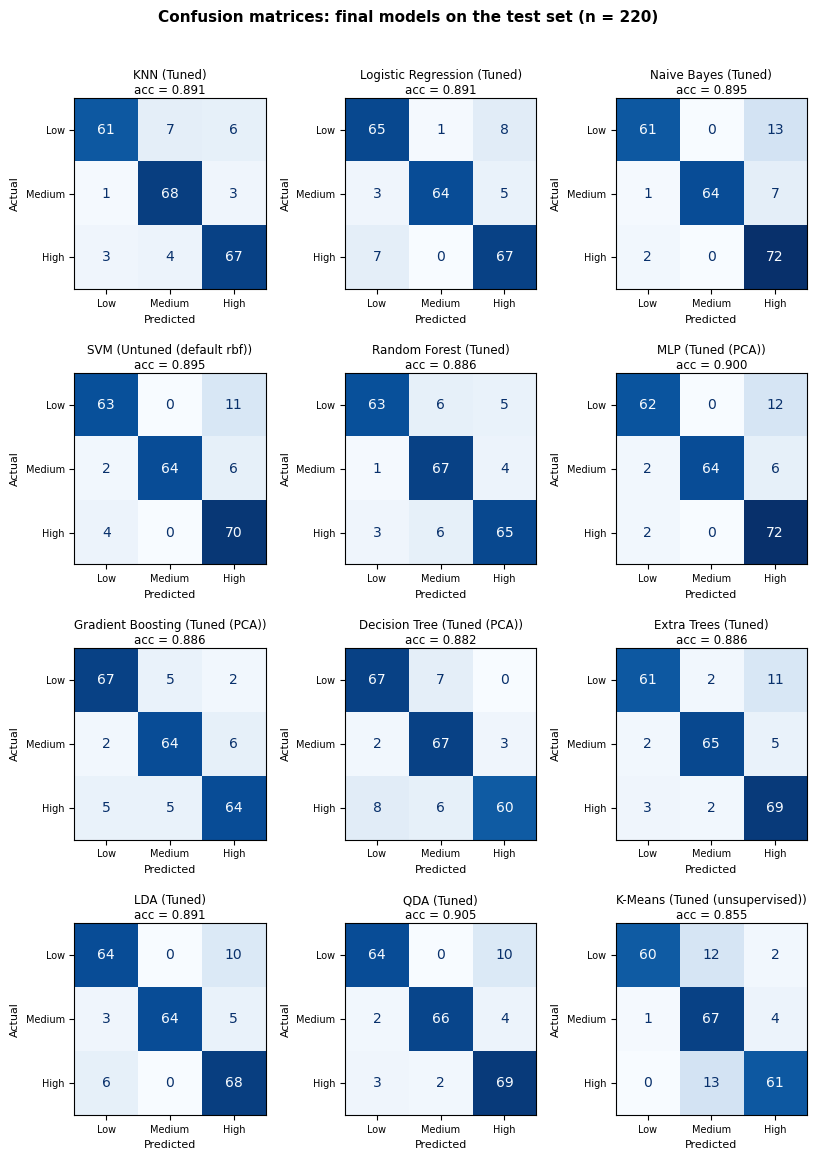

In [22]:
fig, axes = plt.subplots(4, 3, figsize=(8.27, 11.69))
vmax = max(cm.max() for cm in cms.values())

for ax, (name, cm) in zip(axes.ravel(), cms.items()):
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=ax, 
        cmap="Blues", 
        colorbar=False,
        values_format="d"
    )
    ax.images[0].set_clim(0, vmax)
    ax.set_title(
        f"{name} ({REGISTRY[name][2]})\nacc = {results.loc[name, 'Test acc']:.3f}",
        fontsize=8.5,
        pad=3
    )
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)

for ax in axes.ravel()[len(cms):]:
    ax.axis("off")

plt.suptitle(
    "Confusion matrices: final models on the test set (n = %d)" % n_test, 
    fontsize=11, 
    fontweight="bold", 
    y=0.99
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIGS / "final_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Accuracy (with 95% CI) and macro-F1

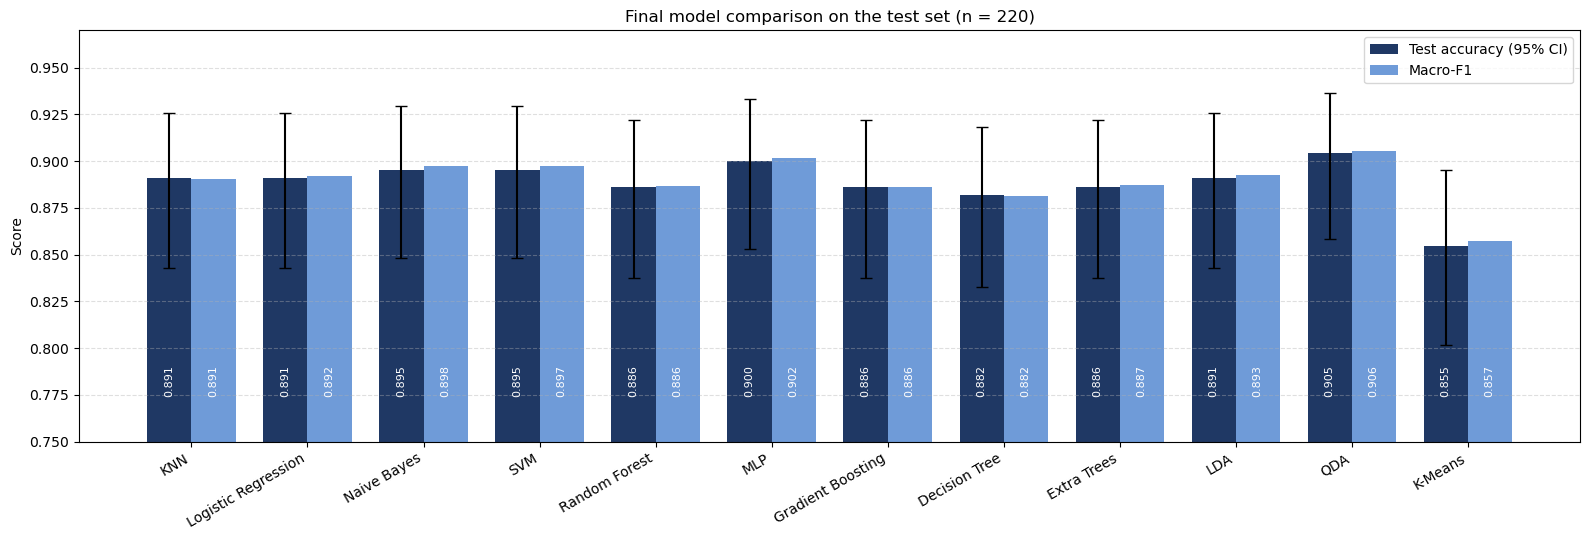

All accuracy confidence intervals share a common overlap: True


In [18]:
order = results.index.tolist()
x = np.arange(len(order)); w = 0.38
acc = results["Test acc"].to_numpy()
err = np.vstack([acc - results["Acc 95% CI low"], results["Acc 95% CI high"] - acc])

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.bar(x - w/2, acc, w, yerr=err, capsize=4, label="Test accuracy (95% CI)", color="#1F3864")
ax.bar(x + w/2, results["Macro-F1"], w, label="Macro-F1", color="#6F9BD8")
for i, (a, f) in enumerate(zip(acc, results["Macro-F1"])):
    ax.text(i - w/2, 0.775, f"{a:.3f}", ha="center", color="white", fontsize=8, rotation=90)
    ax.text(i + w/2, 0.775, f"{f:.3f}", ha="center", color="white", fontsize=8, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylim(0.75, 0.97); ax.set_ylabel("Score")
ax.set_title("Final model comparison on the test set (n = %d)" % n_test)
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

overlap = results["Acc 95% CI low"].max() <= results["Acc 95% CI high"].min()
print("All accuracy confidence intervals share a common overlap:", overlap)

## 7. Per-class recall and the cost of each error type

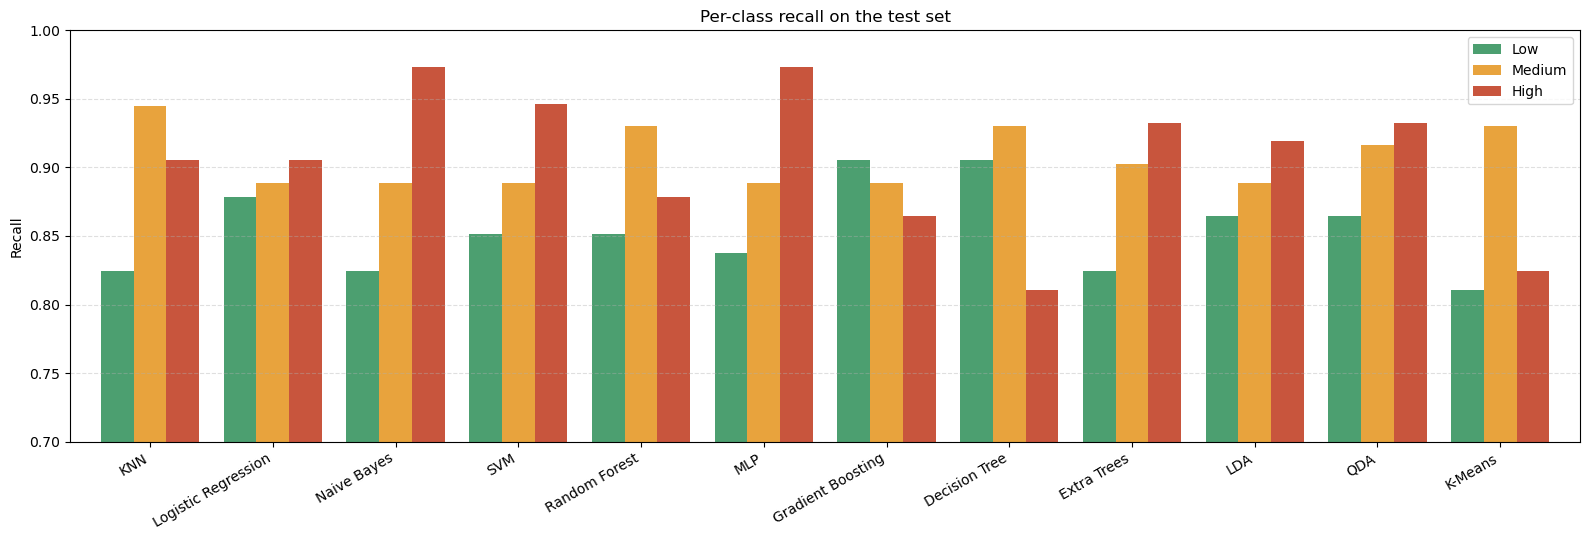

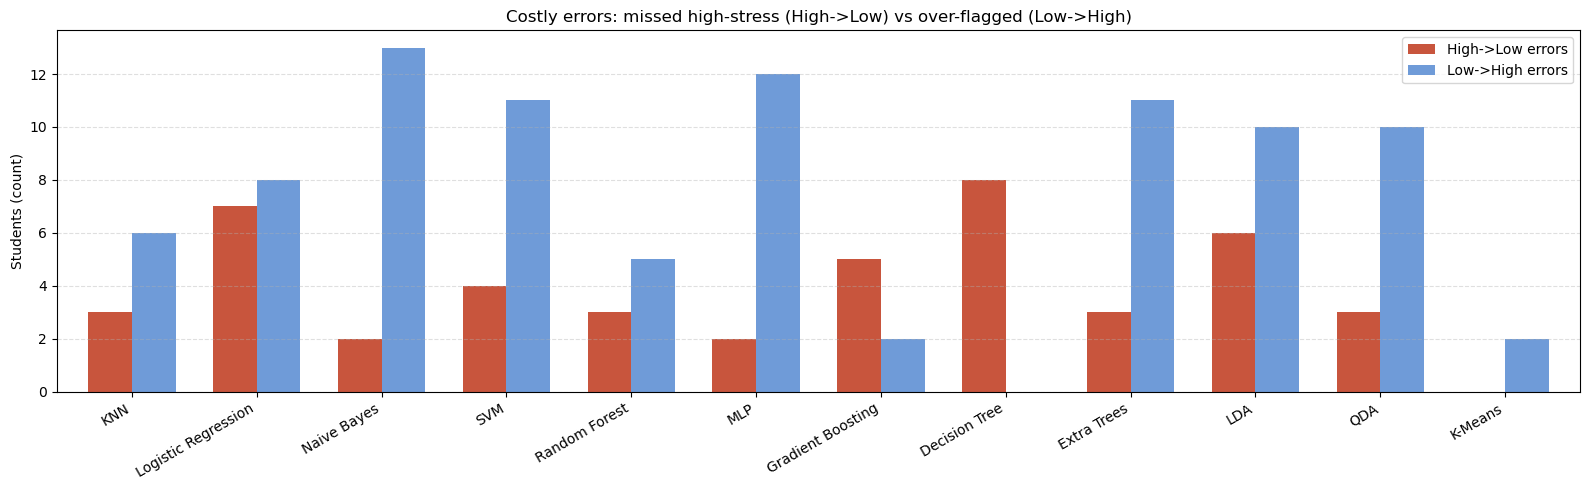

In [19]:
rec = results[["Recall Low", "Recall Medium", "Recall High"]]
rec.columns = LABELS
ax = rec.plot(kind="bar", figsize=(16, 5.5), color=["#4C9F70", "#E8A33D", "#C8553D"], width=0.8)
ax.set_ylim(0.7, 1.0); ax.set_ylabel("Recall"); ax.set_xlabel("")
ax.set_title("Per-class recall on the test set")
ax.grid(axis="y", linestyle="--", alpha=0.4); plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "per_class_recall.png", dpi=150, bbox_inches="tight")
plt.show()

err_df = results[["High->Low errors", "Low->High errors"]]
ax = err_df.plot(kind="bar", figsize=(16, 5), color=["#C8553D", "#6F9BD8"], width=0.7)
ax.set_ylabel("Students (count)"); ax.set_xlabel("")
ax.set_title("Costly errors: missed high-stress (High->Low) vs over-flagged (Low->High)")
ax.grid(axis="y", linestyle="--", alpha=0.4); plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "error_types.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Are the differences real? Pairwise McNemar tests

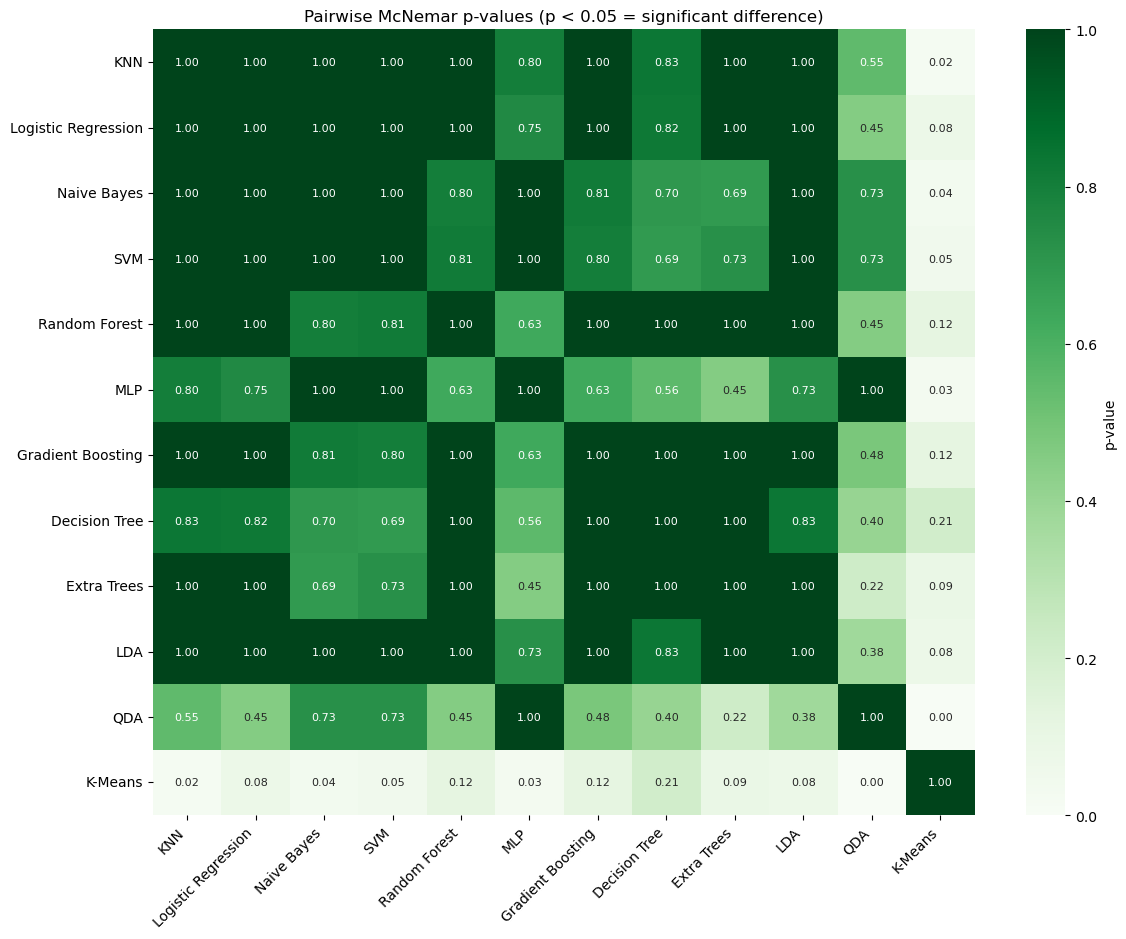

Smallest p-value across all pairs: 0.003
Significant pairs (p < 0.05): 5
  KNN vs K-Means: p = 0.021
  Naive Bayes vs K-Means: p = 0.035
  SVM vs K-Means: p = 0.049
  MLP vs K-Means: p = 0.031
  QDA vs K-Means: p = 0.003


In [20]:
names = list(REGISTRY)
correct = {n: (preds[n] == y_true) for n in names}

pvals = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)
for i, a in enumerate(names):
    for j, b in enumerate(names):
        if i == j:
            continue
        only_a = int((correct[a] & ~correct[b]).sum())   # a right, b wrong
        only_b = int((~correct[a] & correct[b]).sum())   # a wrong, b right
        disc = only_a + only_b
        pvals.loc[a, b] = 1.0 if disc == 0 else binomtest(min(only_a, only_b), disc, 0.5).pvalue

plt.figure(figsize=(12, 9.5))
sns.heatmap(pvals, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, annot_kws={"size": 8}, cbar_kws={"label": "p-value"})
plt.xticks(rotation=45, ha="right")
plt.title("Pairwise McNemar p-values (p < 0.05 = significant difference)")
plt.tight_layout()
plt.savefig(FIGS / "mcnemar_pvalues.png", dpi=150, bbox_inches="tight")
plt.show()

off = pvals.values[~np.eye(len(names), dtype=bool)]
print(f"Smallest p-value across all pairs: {off.min():.3f}")
sig = [(a, b, pvals.loc[a, b]) for i, a in enumerate(names) for b in names[i + 1:] if pvals.loc[a, b] < 0.05]
print("Significant pairs (p < 0.05):", len(sig))
for a, b, p in sig:
    print(f"  {a} vs {b}: p = {p:.3f}")

## 9. Summary

In [21]:
best_acc = results["Test acc"].idxmax()
best_f1  = results["Macro-F1"].idxmax()
sup = [m for m in results.index if m not in UNSUPERVISED]      # K-Means excluded: it over-assigns Medium
fewest_missed = results.loc[sup, "High->Low errors"].min()
print(f"Highest test accuracy : {best_acc} ({results.loc[best_acc, 'Test acc']:.3f})")
print(f"Highest macro-F1      : {best_f1} ({results.loc[best_f1, 'Macro-F1']:.3f})")
print("Fewest missed high-stress students among supervised models (High->Low = %d): %s" %
      (fewest_missed, ", ".join(m for m in sup if results.loc[m, "High->Low errors"] == fewest_missed)))
print(f"Accuracy range        : {results['Test acc'].min():.3f} to {results['Test acc'].max():.3f} "
      f"({results['Correct'].max() - results['Correct'].min()} samples out of {n_test})")
print(f"Significant McNemar pairs: {len(sig)}")

summary = results[["Final model", "Test acc", "Macro-F1"]].join(cv_df[["CV acc mean", "CV acc std"]]).round(3)
display(summary)
summary.to_csv(OUT / "model_comparison_summary.csv")

Highest test accuracy : QDA (0.905)
Highest macro-F1      : QDA (0.906)
Fewest missed high-stress students among supervised models (High->Low = 2): Naive Bayes, MLP
Accuracy range        : 0.855 to 0.905 (11 samples out of 220)
Significant McNemar pairs: 5


,Final model,Test acc,Macro-F1,CV acc mean,CV acc std
Model,,,,,
KNN,Tuned,0.891,0.891,0.885,0.030
Logistic Regression,Tuned,0.891,0.892,0.872,0.032
Naive Bayes,Tuned,0.895,0.898,0.889,0.028
SVM,Untuned (default rbf),0.895,0.897,0.870,0.026
Random Forest,Tuned,0.886,0.886,0.874,0.032
MLP,Tuned (PCA),0.900,0.902,0.886,0.023
Gradient Boosting,Tuned (PCA),0.886,0.886,0.872,0.028
Decision Tree,Tuned (PCA),0.882,0.882,0.875,0.040
Extra Trees,Tuned,0.886,0.887,0.878,0.032
